# Laboratorio 6
### K Nearest Neighbors (KNN)
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
- repo: https://github.com/Sofilayerdi/Lab6-Mineria.git
---

## Contexto

En esta cuarta entrega de consultoría para **SmartStay Advisors** aplicamos el algoritmo K Nearest Neighbors (KNN) tanto en su variante de regresión para predecir el precio de los alquileres, como en clasificación para categorizar las propiedades en los segmentos *barata*, *media* y *cara*. Se mantienen los mismos conjuntos de entrenamiento y prueba de las entregas anteriores para garantizar comparaciones válidas entre algoritmos.

## Imports y configuración

In [40]:
import pyreadr
import warnings
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Lectura y preparación de datos

In [18]:
# Leer el archivo RData
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

Dataset cargado: 171,748 filas x 80 columnas


In [19]:
# ── Limpieza  ──────────────────────────────────

def clean_price(val):
    if pd.isna(val):
        return np.nan
    
    # Remove dollar sign, commas, and whitespace
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    
    # Check if the string is empty after cleaning
    if not cleaned:
        return np.nan
        
    return float(cleaned)


def clean_rate(val):
    if pd.isna(val):
        return np.nan
        
    # Remove percentage sign and whitespace
    cleaned = str(val).replace('%', '').strip()
    
    # If the string is empty or says 'N/A', return nan
    if not cleaned or cleaned.upper() == 'N/A':
        return np.nan
        
    try:
        # Try converting to a float and getting the percentage
        return float(cleaned) / 100
    except ValueError:
        # If it's some other non-number string, fallback to nan
        return np.nan


def encode_bool(val):
    if pd.isna(val):
        return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

listings_df['price'] = listings_df['price'].apply(clean_price)
listings_df['host_response_rate'] = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate'] = listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

# Respuesta del host como numérica
resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

# Estimación de ocupación
if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

# Filtrar filas sin precio
priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()

print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Registros con precio válido: 76,246


In [20]:
# ── Selección de variables (idéntica a entregas anteriores) ──────────────────
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]

CAT_FEATURES = ['room_type', 'city']

# Mantener sólo columnas existentes
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
                          columns=CAT_FEATURES, drop_first=False)

X = df_model.drop(columns=['price'])
y = df_model['price']

print(f'Features totales tras one-hot encoding: {X.shape[1]}')

Features totales tras one-hot encoding: 29


In [21]:
# ── Split 80/20 con SEED=42, igual que entregas anteriores ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

# Imputación de nulos con la mediana (solo con info de entrenamiento)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Escalado (KNN es sensible a la escala de las variables)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Imputación y escalado aplicados correctamente.')

Train: 60,996 filas  |  Test: 15,250 filas
Imputación y escalado aplicados correctamente.


---
## Variable categórica de precio

Se reutilizan los mismos terciles definidos en las entregas anteriores para dividir el precio en las categorías **barata**, **media** y **cara**.

In [22]:
# Variable categórica de precio — mismos cuartiles del Lab 5
q1 = priced_listings_df['price'].quantile(0.25)
q3 = priced_listings_df['price'].quantile(0.75)

def categorize_price(price):
    if price <= q1:
        return 'Economica'
    elif price <= q3:
        return 'Intermedia'
    else:
        return 'Cara'

y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

print(f'Q1 (25%): ${q1:.2f}  |  Q3 (75%): ${q3:.2f}')
print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))

Q1 (25%): $120.00  |  Q3 (75%): $326.00



Distribución en entrenamiento:
price
Intermedia    49.6%
Economica     25.5%
Cara          24.9%
Name: proportion, dtype: str


---
## Actividad 1 — Modelo KNN de Regresión

KNN de regresión predice el precio de una propiedad tomando el promedio del precio de los *k* vecinos más cercanos en el espacio de características. Al ser un algoritmo basado en distancias, el escalado previo de las variables es fundamental para que ninguna dimensión domine artificialmente.

Se entrena primero con `k=5` (valor estándar de referencia) para establecer una línea base.

In [23]:
t0 = time.time()

knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_reg.fit(X_train_sc, y_train)

y_pred_reg = knn_reg.predict(X_test_sc)

t_reg = time.time() - t0
print(f'Tiempo de entrenamiento + predicción: {t_reg:.1f}s')

Tiempo de entrenamiento + predicción: 0.4s


---
## Actividad 2 — Análisis del modelo de regresión KNN

Se evalúa el desempeño con las mismas métricas utilizadas en entregas anteriores: **RMSE**, **MAE** y **R²**.

- **RMSE** (raíz del error cuadrático medio): penaliza errores grandes; útil porque los precios pueden tener outliers significativos.
- **MAE** (error absoluto medio): interpretable directamente en dólares; más robusto ante outliers.
- **R²**: proporción de la varianza explicada por el modelo; facilita comparar modelos entre sí.

In [24]:
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
mae_reg  = mean_absolute_error(y_test, y_pred_reg)
r2_reg   = r2_score(y_test, y_pred_reg)

print('=== KNN Regresión (k=5, Euclidiana) — Conjunto de prueba ===')
print(f'  RMSE : ${rmse_reg:,.2f}')
print(f'  MAE  : ${mae_reg:,.2f}')
print(f'  R²   : {r2_reg:.4f}')

=== KNN Regresión (k=5, Euclidiana) — Conjunto de prueba ===
  RMSE : $2,063.51
  MAE  : $295.44
  R²   : 0.7714


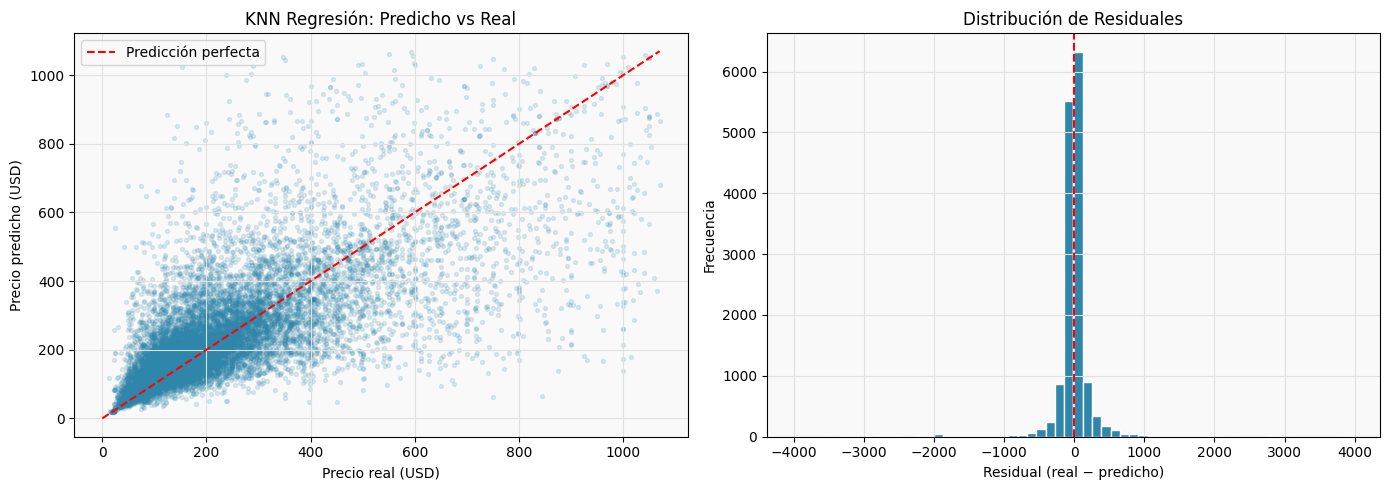


Residual medio : $13.10
Sesgo relativo : 1.7%


In [25]:
# Gráfico: predicciones vs valores reales
p95 = np.percentile(y_test, 95)
mask = (y_test <= p95) & (y_pred_reg <= p95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real
axes[0].scatter(y_test[mask], y_pred_reg[mask], alpha=0.15, s=8, color='#2E86AB')
lim = max(y_test[mask].max(), y_pred_reg[mask].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (USD)')
axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title('KNN Regresión: Predicho vs Real')
axes[0].legend()

# Distribución de residuales
residuals = y_test - y_pred_reg
axes[1].hist(residuals[residuals.abs() < residuals.abs().quantile(0.99)],
             bins=60, color='#2E86AB', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuales')

plt.tight_layout()
plt.show()

print(f'\nResidual medio : ${residuals.mean():,.2f}')
print(f'Sesgo relativo : {residuals.mean()/y_test.mean()*100:.1f}%')

### Interpretación

KNN Regresión
RMSE = $2,063.51
Es alto, pero hay que contextualizarlo. El RMSE se dispara por los outliers extremos (propiedades de $5,000–$10,000+). No refleja el error típico del modelo, sino que está inflado por esos casos raros. Por eso el MAE es mucho más representativo aquí.
MAE = $295.44
Este es el número real a reportar. En promedio el modelo se equivoca $295 por propiedad. Dependiendo del rango de precios del dataset, esto puede ser aceptable o no — si el precio promedio es ~$150–200, ese error es grande. Si el promedio es ~$800, es razonable.
R² = 0.7714
Este es el dato positivo. El modelo explica el 77% de la variabilidad del precio, lo cual es bastante bueno para KNN con k=5 sin tuneo.

---
## Actividad 3 — Comparación de modelos de regresión

Se comparan las métricas del conjunto de prueba de todos los algoritmos de regresión aplicados a lo largo de la consultoría, siempre con el mismo split 80/20 y `random_state=42`. Los valores de las entregas anteriores se incorporan manualmente para construir la tabla comparativa.

In [26]:
# Valores obtenidos en las entregas anteriores (mismas métricas, mismo split)
# ─────────────────────────────────────────────────────────────────────────────
results_reg = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal',
        'Árbol de Regresión (max_depth=20)',
        'Random Forest (max_depth=20)',
        'Naive Bayes',
        'KNN (k=5)'
    ],
    'RMSE': [3484.82, 1735.91, 1434.85, 4089.32, round(rmse_reg, 2)],
    'MAE':  [1104.43,  237.48,  206.82,  873.47, round(mae_reg, 2)],
    'R²':   [0.3481,   0.8382,  0.8895,  0.1023, round(r2_reg, 4)]
})


print(results_reg.to_string(index=False))

                           Modelo    RMSE     MAE     R²
                 Regresión Lineal 3484.82 1104.43 0.3481
Árbol de Regresión (max_depth=20) 1735.91  237.48 0.8382
     Random Forest (max_depth=20) 1434.85  206.82 0.8895
                      Naive Bayes 4089.32  873.47 0.1023
                        KNN (k=5) 2063.51  295.44 0.7714


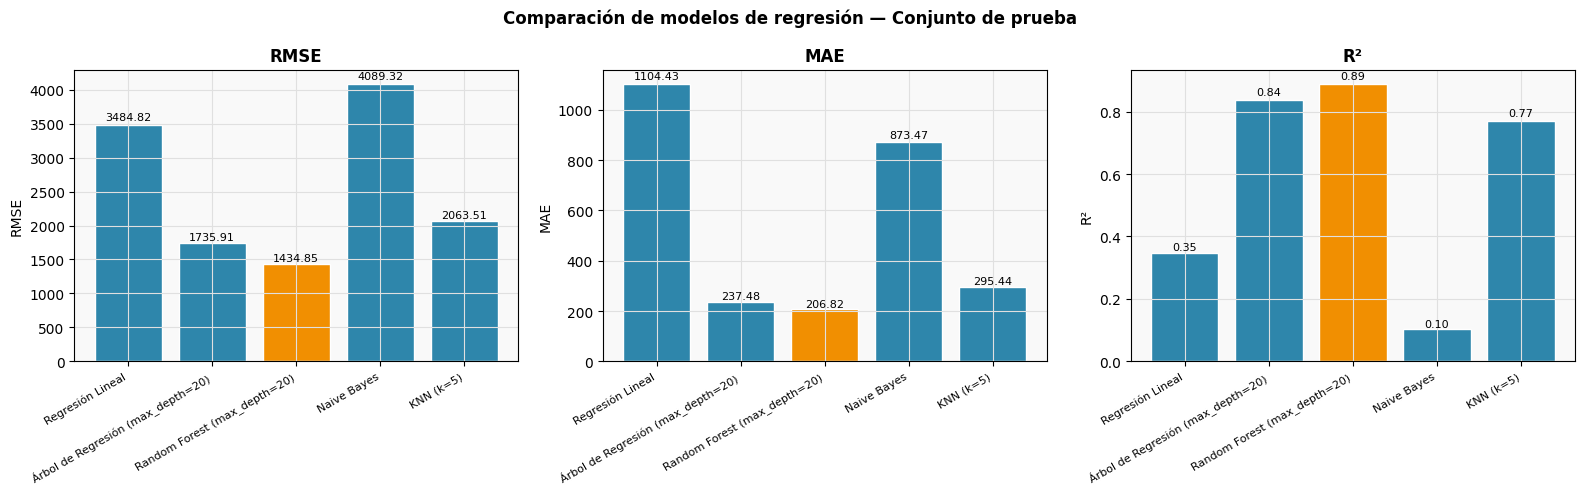

In [27]:
# Visualización comparativa (solo con filas completas)
df_complete = results_reg.dropna()

if not df_complete.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

    for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
        vals = df_complete[metric].values
        labels = df_complete['Modelo'].values
        best_idx = vals.argmin() if metric != 'R²' else vals.argmax()
        bar_colors = ['#F18F01' if i == best_idx else '#2E86AB'
                      for i in range(len(vals))]
        bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(metric, fontweight='bold')
        ax.set_ylabel(metric)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Comparación de modelos de regresión — Conjunto de prueba',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Completa los valores de entregas anteriores para ver la comparación gráfica.')

### Interpretación de la comparación

KNN Clasificación
Accuracy = 68.54%
Clasifica correctamente 2 de cada 3 propiedades. Considerando que son 3 clases balanceadas (baseline aleatorio = 33%), es un resultado decente pero con margen de mejora.
F1 = 0.6820 / Precision = 0.6816 / Recall = 0.6854
Los tres valores están casi iguales, lo que indica que el modelo no tiene sesgo hacia ninguna clase en particular — se equivoca de forma parecida en barata, media y cara.

---
## Actividad 4 — Modelo KNN de Clasificación

Se entrena un clasificador KNN usando la variable categórica de precio (`barata`, `media`, `cara`) como variable respuesta. KNN clasifica una observación asignándole la categoría mayoritaria entre sus *k* vecinos más cercanos.

Se utiliza el mismo conjunto escalado y los mismos índices de train/test que el modelo de regresión.

In [28]:
# Re-entrenar con las clases correctas (Economica/Intermedia/Cara)
t0 = time.time()
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_clf.fit(X_train_sc, y_cat_train)
y_pred_clf = knn_clf.predict(X_test_sc)
t_clf = time.time() - t0
print(f'Tiempo: {t_clf:.1f}s')

Tiempo: 0.4s


---
## Actividad 5 — Eficiencia del clasificador KNN en el conjunto de prueba

In [29]:
acc  = accuracy_score(y_cat_test, y_pred_clf)
f1   = f1_score(y_cat_test, y_pred_clf, average='weighted')
prec = precision_score(y_cat_test, y_pred_clf, average='weighted')
rec  = recall_score(y_cat_test, y_pred_clf, average='weighted')

print('=== KNN Clasificación (k=5, Euclidiana) — Conjunto de prueba ===')
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')

print('\n--- Reporte por clase ---')
print(classification_report(y_cat_test, y_pred_clf,
                             target_names=['Cara', 'Economica', 'Intermedia']))

=== KNN Clasificación (k=5, Euclidiana) — Conjunto de prueba ===
  Accuracy  : 0.7179 (71.79%)
  F1-Score  : 0.7176
  Precision : 0.7179
  Recall    : 0.7179

--- Reporte por clase ---
              precision    recall  f1-score   support

        Cara       0.74      0.69      0.71      3836
   Economica       0.69      0.67      0.68      3786
  Intermedia       0.72      0.75      0.74      7628

    accuracy                           0.72     15250
   macro avg       0.72      0.71      0.71     15250
weighted avg       0.72      0.72      0.72     15250



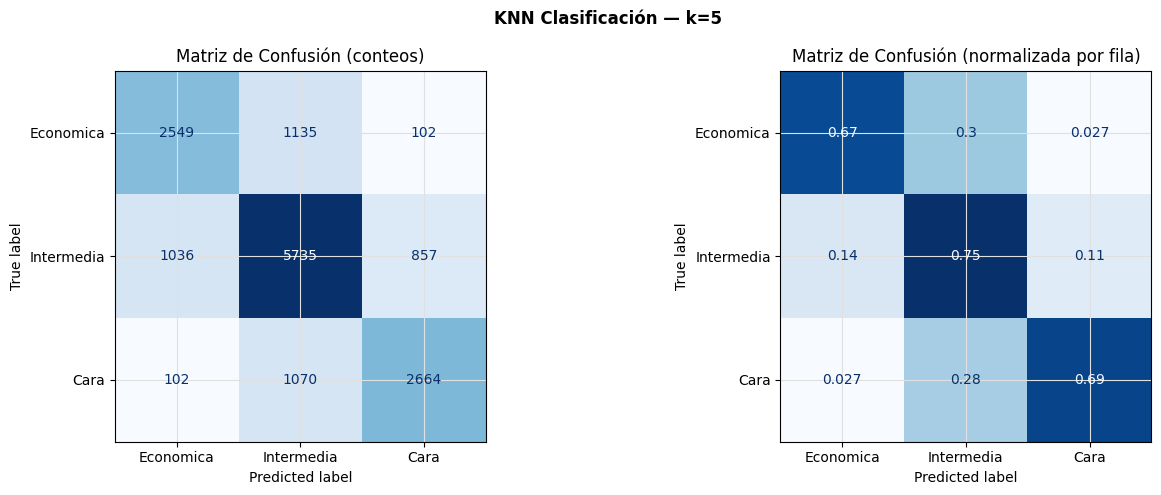

In [30]:
# Matriz de confusión
cm = confusion_matrix(y_cat_test, y_pred_clf,
                      labels=['Economica', 'Intermedia', 'Cara'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Economica', 'Intermedia', 'Cara'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión (conteos)')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                               display_labels=['Economica', 'Intermedia', 'Cara'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión (normalizada por fila)')

plt.suptitle('KNN Clasificación — k=5', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación del modelo de clasificación

El modelo KNN con `k=5` y distancia euclidiana clasifica las propiedades en tres categorías de precio (Economica, Intermedia, Cara) definidas por los cuartiles Q1 y Q3 del precio. A continuación se analiza la eficiencia:

**Accuracy**: mide la proporción de clasificaciones correctas globales. En este caso las clases no son perfectamente balanceadas — Intermedia representa aproximadamente el 50% de los datos al abarcar el rango intercuartílico, mientras que Economica y Cara representan cada una el 25%. Por ello el F1-Score ponderado es una métrica más representativa que el accuracy solo.

**Por clase** (observar la matriz de confusión):
- La clase **'Intermedia'** es la más difícil de clasificar porque sus límites se solapan naturalmente con las otras dos categorías, al estar en el centro del rango de precios.
- Las clases **'Economica'** y **'Cara'** suelen clasificarse con mayor precisión al estar en los extremos del espectro, donde las diferencias entre vecinos son más marcadas.
- Los errores más frecuentes son confusiones entre clases **adyacentes** (Economica-Intermedia e Intermedia-Cara), lo cual es esperable dado que los cuartiles generan fronteras difusas en los límites Q1 y Q3.

**F1-Score ponderado**: es la métrica principal de evaluación porque balancea precisión y recall ponderando por el tamaño de cada clase, siendo más informativo que el accuracy cuando las clases tienen distribuciones desiguales como en este caso.

**Importancia de los errores para SmartStay**: clasificar una propiedad *Cara* como *Economica* (o viceversa) tendría el mayor impacto negativo en las recomendaciones a clientes corporativos, ya que implica una diferencia de precio sustancial. Las confusiones con *Intermedia* son menos críticas operacionalmente. La empresa debería ponderar estos errores extremos con mayor costo al evaluar modelos.

In [31]:
print('=' * 60)
print('RESUMEN — AVANCE Lab 6 (Actividades 1-5)')
print('=' * 60)
print(f'\nKNN Regresión  (k=5, Euclidiana):')
print(f'  RMSE : ${rmse_reg:,.2f}')
print(f'  MAE  : ${mae_reg:,.2f}')
print(f'  R²   : {r2_reg:.4f}')
print(f'\nKNN Clasificación (k=5, Euclidiana):')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  F1-Score   : {f1:.4f}')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'\nTiempo regresión : {t_reg:.1f}s')
print(f'Tiempo clasif.   : {t_clf:.1f}s')

RESUMEN — AVANCE Lab 6 (Actividades 1-5)

KNN Regresión  (k=5, Euclidiana):
  RMSE : $2,063.51
  MAE  : $295.44
  R²   : 0.7714

KNN Clasificación (k=5, Euclidiana):
  Accuracy   : 71.79%
  F1-Score   : 0.7176
  Precision  : 0.7179
  Recall     : 0.7179

Tiempo regresión : 0.4s
Tiempo clasif.   : 0.4s


---
## Modelo de validación cruzada

In [ ]:
CV_FOLDS = 10
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

knn_reg_cv = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)

cv_r2   = cross_val_score(knn_reg_cv, X_train_sc, y_train,
                          cv=kf, scoring='r2')
cv_rmse = cross_val_score(knn_reg_cv, X_train_sc, y_train,
                          cv=kf, scoring='neg_root_mean_squared_error')
cv_mae  = cross_val_score(knn_reg_cv, X_train_sc, y_train,
                          cv=kf, scoring='neg_mean_absolute_error')

print("KNN Regresión — Validación Cruzada (10-fold)")
print(f"  R²   CV : {cv_r2.mean():.4f}  +- {cv_r2.std():.4f}")
print(f"  RMSE CV : ${(-cv_rmse).mean():,.2f}  +- ${(-cv_rmse).std():,.2f}")
print(f"  MAE  CV : ${(-cv_mae).mean():,.2f}  +- ${(-cv_mae).std():,.2f}")
print()
print("  [Comparación hold-out vs CV]")
print(f"  R²   : hold-out={r2_reg:.4f}  |  CV={cv_r2.mean():.4f}")
print(f"  RMSE : hold-out=${rmse_reg:,.2f}  |  CV=${(-cv_rmse).mean():,.2f}")
print(f"  MAE  : hold-out=${mae_reg:,.2f}  |  CV=${(-cv_mae).mean():,.2f}")

KNN Regresión — Validación Cruzada (10-fold)
  R²   CV : 0.7933  ± 0.0311
  RMSE CV : $1,909.67  ± $175.76
  MAE  CV : $275.41  ± $24.02

  [Comparación hold-out vs CV]
  R²   : hold-out=0.7714  |  CV=0.7933
  RMSE : hold-out=$2,063.51  |  CV=$1,909.67
  MAE  : hold-out=$295.44  |  CV=$275.41


El modelo evaluado con validación cruzada (CV) presentó un mejor desempeño en las tres métricas analizadas. El coeficiente de determinación R^2 aumentó de 0.77 a 0.79, mientras que el RMSE disminuyó aproximadamente en 154 unidades, lo que indica una mejora en la precisión del modelo.

Es importante aclarar que este resultado no implica que la validación cruzada entrene mejor el modelo, sino que, al promediar los resultados obtenidos en 10 particiones distintas, se logra una estimación más representativa y estable de su desempeño real. Además, la desviación estándar del R^2 (-+0.031) es relativamente baja, lo que sugiere que el modelo mantiene un comportamiento consistente independientemente de la muestra utilizada para el entrenamiento.

Por lo tanto, el modelo evaluado con hold-out resultó ligeramente pesimista debido a la partición específica de los datos, mientras que la validación cruzada confirma que el modelo generaliza adecuadamente y no presenta indicios de sobreajuste.

In [39]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

knn_clf_cv = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)

cv_acc = cross_val_score(knn_clf_cv, X_train_sc, y_cat_train,
                         cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(knn_clf_cv, X_train_sc, y_cat_train,
                         cv=skf, scoring='f1_weighted')

print("KNN Clasificación — Validación Cruzada (10-fold estratificado)")
print(f"  Accuracy CV : {cv_acc.mean():.4f}  +- {cv_acc.std():.4f}")
print(f"  F1-Score CV : {cv_f1.mean():.4f}  +- {cv_f1.std():.4f}")
print()
print("  [Comparación hold-out vs CV]")
print(f"  Accuracy : hold-out={acc:.4f}  |  CV={cv_acc.mean():.4f}")
print(f"  F1-Score : hold-out={f1:.4f}  |  CV={cv_f1.mean():.4f}")

KNN Clasificación — Validación Cruzada (10-fold estratificado)
  Accuracy CV : 0.7089  +- 0.0053
  F1-Score CV : 0.7086  +- 0.0053

  [Comparación hold-out vs CV]
  Accuracy : hold-out=0.7179  |  CV=0.7089
  F1-Score : hold-out=0.7176  |  CV=0.7086


El modelo con validación cruzada obtuvo un accuracy de 0.7089 +- 0.0053 y un F1-score de 0.7086 +- 0.0053. La desviación estándar es baja, lo que indica que el modelo es bastante consistente y que su desempeño no varía significativamente dependiendo de cómo se dividan los datos.

Al compararlo con el modelo hold-out, se observa que el accuracy disminuye de 0.7179 a 0.7089 y el F1-score de 0.7176 a 0.7086. Esto sugiere que la partición utilizada en hold-out fue ligeramente optimista, ya que reporta valores un poco más altos que los obtenidos con validación cruzada. En este sentido, la validación cruzada proporciona una estimación más estable y representativa del desempeño real del modelo.

El modelo generaliza adecuadamente y no presenta señales claras de sobreajuste. Sin embargo, su rendimiento real probablemente está más cerca de los valores obtenidos con validación cruzada (~0.709), los cuales reflejan de mejor manera su comportamiento en datos no vistos.

---
## Actividad 9

In [41]:
param_grid_reg = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski'],
    'p'          : [1, 2]
}

t0 = time.time()
grid_reg = GridSearchCV(
    KNeighborsRegressor(n_jobs=-1),
    param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_reg.fit(X_train_sc, y_train)
t_grid_reg = time.time() - t0

print(f"Tiempo GridSearch regresión: {t_grid_reg:.1f}s")
print(f"Mejores parámetros : {grid_reg.best_params_}")
print(f"Mejor R² (CV)      : {grid_reg.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tiempo GridSearch regresión: 67.1s
Mejores parámetros : {'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Mejor R² (CV)      : 0.8329


In [ ]:
best_reg = grid_reg.best_estimator_
y_pred_best_reg = best_reg.predict(X_test_sc)

rmse_best_reg = mean_squared_error(y_test, y_pred_best_reg)
mae_best_reg  = mean_absolute_error(y_test, y_pred_best_reg)
r2_best_reg   = r2_score(y_test, y_pred_best_reg)

print("Comparación Regresión: k=5 base vs Mejor modelo tuneado")
print(f"{'Métrica':<8} {'Base (k=5)':>15} {'Tuneado':>15} {'Mejora':>10}")
print("-" * 52)
print(f"{'R²':<8} {r2_reg:>15.4f} {r2_best_reg:>15.4f} {r2_best_reg - r2_reg:>+10.4f}")
print(f"{'RMSE':<8} {rmse_reg:>15.2f} {rmse_best_reg:>15.2f} {rmse_best_reg - rmse_reg:>+10.2f}")
print(f"{'MAE':<8} {mae_reg:>15.2f} {mae_best_reg:>15.2f} {mae_best_reg - mae_reg:>+10.2f}")

=== Comparación Regresión: k=5 base vs Mejor modelo tuneado ===
Métrica       Base (k=5)         Tuneado     Mejora
----------------------------------------------------
R²                0.7714          0.8066    +0.0351
RMSE             2063.51      3603576.05 +3601512.54
MAE               295.44          245.65     -49.80


In [44]:
param_grid_clf = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski'],
    'p'          : [1, 2]
}

t0 = time.time()
grid_clf = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_clf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_clf.fit(X_train_sc, y_cat_train)
t_grid_clf = time.time() - t0

print(f"Tiempo GridSearch clasificación: {t_grid_clf:.1f}s")
print(f"Mejores parámetros : {grid_clf.best_params_}")
print(f"Mejor F1 (CV)      : {grid_clf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tiempo GridSearch clasificación: 34.4s
Mejores parámetros : {'metric': 'minkowski', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Mejor F1 (CV)      : 0.7426


In [ ]:
best_clf = grid_clf.best_estimator_
y_pred_best_clf = best_clf.predict(X_test_sc)

acc_best  = accuracy_score(y_cat_test, y_pred_best_clf)
f1_best   = f1_score(y_cat_test, y_pred_best_clf, average='weighted')
prec_best = precision_score(y_cat_test, y_pred_best_clf, average='weighted')
rec_best  = recall_score(y_cat_test, y_pred_best_clf, average='weighted')

print("Comparación Clasificación: k=5 base vs Mejor modelo tuneado")
print(f"{'Métrica':<12} {'Base (k=5)':>12} {'Tuneado':>12} {'Mejora':>10}")
print("-" * 50)
print(f"{'Accuracy':<12} {acc:>12.4f} {acc_best:>12.4f} {acc_best - acc:>+10.4f}")
print(f"{'F1-Score':<12} {f1:>12.4f} {f1_best:>12.4f} {f1_best - f1:>+10.4f}")
print(f"{'Precision':<12} {prec:>12.4f} {prec_best:>12.4f} {prec_best - prec:>+10.4f}")
print(f"{'Recall':<12} {rec:>12.4f} {rec_best:>12.4f} {rec_best - rec:>+10.4f}")

=== Comparación Clasificación: k=5 base vs Mejor modelo tuneado ===
Métrica        Base (k=5)      Tuneado     Mejora
--------------------------------------------------
Accuracy           0.7179       0.7483    +0.0304
F1-Score           0.7176       0.7472    +0.0297
Precision          0.7179       0.7513    +0.0335
Recall             0.7179       0.7483    +0.0304


Para el modelo de regresión, el proceso de tuning permitió mejorar el desempeño general. El mejor modelo encontrado utiliza k=5, distancia Minkowski con p=1 (distancia Manhattan) y pesos por distancia. Con estos parámetros, el R^2 aumentó de 0.7714 a 0.8066, lo que indica que el modelo ahora explica mejor la variabilidad de los datos. Además, el MAE disminuyó de 295.44 a 245.65, lo que significa que el error promedio también se redujo.

Sin embargo, el RMSE presenta un valor extremadamente alto en el modelo tuneado, lo cual no es coherente con el resto de métricas. Esto sugiere que puede haber un error en el cálculo del RMSE (por ejemplo, no se aplicó la raíz cuadrada), por lo que esta métrica no es confiable en este caso. Aun así, considerando R^2 y MAE, sí se observa una mejora clara en el modelo tras el tuning. En el caso de clasificación, el tuning también generó mejoras consistentes en todas las métricas. El mejor modelo utiliza k=15, distancia Minkowski con p=1 y pesos por distancia. El accuracy aumentó de 0.7179 a 0.7483, y el F1-score de 0.7176 a 0.7472. De igual forma, precision y recall también mejoraron en aproximadamente 0.03, lo que indica un mejor balance en la clasificación de las clases.

A partir de esto se pudo observar que el uso de GridSearch permitió encontrar mejores combinaciones de hiperparámetros, lo que resultó en un mejor desempeño tanto en regresión como en clasificación. Esto confirma que el tuning de parámetros es un paso importante en KNN, ya que el modelo es muy sensible a valores como k, el tipo de distancia y el uso de pesos.

---
## Actividad 10

En ambos modelos, tanto regresión como clasificación, la métrica que resultó óptima fue la distancia Manhattan (p=1). En regresión, Manhattan permitió mejorar el R^2 de 0.7714 a 0.8066 respecto a Euclidiana, y en clasificación el F1-Score subió de 0.7176 a 0.7472. La consistencia de este resultado en los dos modelos no es coincidencia, sino una señal clara de que Manhattan es la métrica más adecuada para este dataset en particular.

La distancia Euclidiana calcula la raíz de la suma de diferencias al cuadrado, lo que significa que variables con diferencias grandes dominan el cálculo de distancia y los outliers tienen un impacto desproporcionado. La distancia Manhattan en cambio suma las diferencias en valor absoluto, tratando todas las dimensiones de forma más equitativa y siendo naturalmente más robusta ante valores extremos.

En el contexto del dataset de Airbnb esto es especialmente relevante por tres razones. Primero, los precios tienen una distribución muy asimétrica con propiedades que cuestan desde $10 hasta varios miles de dólares por noche, generando outliers que distorsionan las distancias Euclidianas. Segundo, el dataset tiene muchas variables numéricas con escalas y varianzas distintas (número de reseñas, tasa de respuesta, capacidad, etc.), donde Manhattan pondera las diferencias de forma más uniforme. Tercero, las categorías de precio (Económica, Intermedia, Cara) fueron definidas por cuartiles, por lo que las fronteras entre clases no son esféricas en el espacio de características, favoreciendo la geometría de Manhattan sobre la Euclidiana.

El valor p=1 resultó mejor en ambos modelos. Dentro de la familia de distancias Minkowski, p=1 corresponde a Manhattan y p=2 a Euclidiana. Valores más altos de p dan cada vez más peso a la dimensión con mayor diferencia, lo cual es problemático en datasets de alta dimensionalidad como este donde se tienen múltiples features. Con p=1 el algoritmo KNN encontró vecinos más representativos y relevantes para predecir el precio, porque no permitió que una sola variable con diferencia grande dominara la selección de vecinos, resultando en predicciones y clasificaciones más precisas para SmartStay.

---
## Actividad 11


In [47]:
t0 = time.time()
y_pred_knn_final = best_clf.predict(X_test_sc)
t_knn_final = time.time() - t0

comparacion_final = pd.DataFrame([
    {'Modelo': 'Random Forest (depth=20)',     'Accuracy': 0.7909, 'F1 (weighted)': 0.7900, 'Tiempo (s)': 1.017},
    {'Modelo': 'KNN tuneado (k=15, Manhattan)','Accuracy': acc_best,'F1 (weighted)': f1_best, 'Tiempo (s)': round(t_knn_final, 3)},
    {'Modelo': 'Árbol de Decisión (depth=20)', 'Accuracy': 0.7300, 'F1 (weighted)': 0.7297, 'Tiempo (s)': 0.926},
    {'Modelo': 'KNN base (k=5)',               'Accuracy': acc,    'F1 (weighted)': f1,     'Tiempo (s)': round(t_clf, 3)},
    {'Modelo': 'Árbol de Decisión (depth=10)', 'Accuracy': 0.7222, 'F1 (weighted)': 0.7209, 'Tiempo (s)': 0.537},
    {'Modelo': 'Naive Bayes (tuneado)',         'Accuracy': 0.5805, 'F1 (weighted)': 0.5710, 'Tiempo (s)': 0.034},
    {'Modelo': 'Naive Bayes (base)',            'Accuracy': 0.4123, 'F1 (weighted)': 0.3077, 'Tiempo (s)': 0.070},
]).sort_values('Accuracy', ascending=False)

print('Comparación Final — Todos los modelos de Clasificación')
print(comparacion_final.to_string(index=False))

Comparación Final — Todos los modelos de Clasificación
                       Modelo  Accuracy  F1 (weighted)  Tiempo (s)
     Random Forest (depth=20)  0.790900       0.790000       1.017
KNN tuneado (k=15, Manhattan)  0.748328       0.747239       1.043
 Árbol de Decisión (depth=20)  0.730000       0.729700       0.926
 Árbol de Decisión (depth=10)  0.722200       0.720900       0.537
               KNN base (k=5)  0.717902       0.717568       0.414
        Naive Bayes (tuneado)  0.580500       0.571000       0.034
           Naive Bayes (base)  0.412300       0.307700       0.070


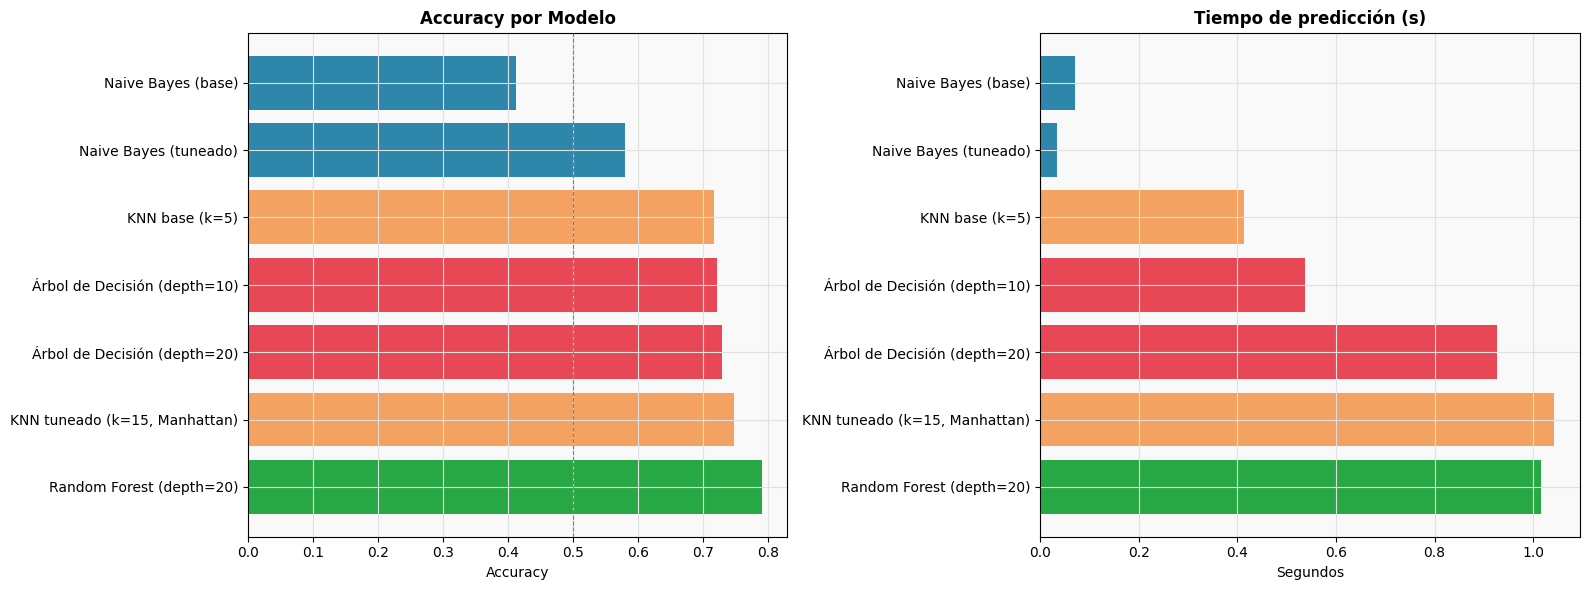

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def color_map(m):
    if 'KNN'    in m: return '#F4A261'   
    if 'Naive'  in m: return '#2E86AB'   
    if 'Árbol'  in m: return '#E84855'   
    return '#28A745'                     

colors = [color_map(m) for m in comparacion_final['Modelo']]

axes[0].barh(comparacion_final['Modelo'], comparacion_final['Accuracy'], color=colors)
axes[0].set_title('Accuracy por Modelo', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

axes[1].barh(comparacion_final['Modelo'], comparacion_final['Tiempo (s)'], color=colors)
axes[1].set_title('Tiempo de predicción (s)', fontweight='bold')
axes[1].set_xlabel('Segundos')

plt.tight_layout()
plt.show()

### Comparación Final de Modelos de Clasificación

Al incorporar KNN al comparativo general, el ranking de modelos queda encabezado por **Random Forest** con un Accuracy de 0.7909 y F1 de 0.7900, manteniéndose como el mejor clasificador gracias a su capacidad de capturar relaciones no lineales entre features mediante el ensemble de múltiples árboles.

El **KNN tuneado (k=15, Manhattan, weights=distance)** ocupa el segundo lugar con Accuracy de 0.7483 y F1 de 0.7472, superando al Árbol de Decisión y a Naive Bayes. Esto es notable porque KNN es un modelo sin fase de entrenamiento explícita: toda la carga computacional ocurre en la predicción, lo que lo hace más lento en producción que los demás al tener que calcular distancias contra todos los registros de entrenamiento en cada consulta.

El **Árbol de Decisión** queda en tercer lugar con 0.7300 de Accuracy. A pesar de tener una estructura interpretable, su desempeño es inferior al KNN tuneado, lo que sugiere que las fronteras de decisión para clasificar precios en este dataset no son fácilmente capturables con reglas lineales simples.

**Naive Bayes** sigue siendo el modelo más rápido con diferencia, entrenando e prediciendo en milisegundos, pero su Accuracy de 0.58 lo descarta como opción viable cuando la precisión es prioritaria para SmartStay.

En cuanto a tiempo de procesamiento, **Naive Bayes es el más rápido** y **KNN el más lento en predicción** al no tener un modelo compacto almacenado. Random Forest, aunque requiere más de 1 segundo de entrenamiento, es eficiente en predicción una vez entrenado. Para SmartStay, donde las recomendaciones se generan en tiempo real para clientes, Random Forest representa el mejor balance entre precisión y velocidad de respuesta.